In [ ]:
import jax.numpy as jnp
import numpy as np
import jax
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [ ]:
burnin = 1000
beta = 0.3
N = 1000
seed = 0

In [ ]:
key = jax.random.key(seed)

In [ ]:
def project(v, n):
    return v - jnp.dot(v, n)/jnp.dot(n, n) * n

def log_r(x, xi, y, xi_prime, beta):
  return 0.5 * (jnp.linalg.norm(x)**2 - jnp.linalg.norm(y)**2) + (1 / (2 * beta**2)) * (jnp.linalg.norm(xi)**2 - jnp.linalg.norm(xi_prime)**2)

def compute_reverse(x, y, n, beta):
    return project(x-jnp.sqrt(1-beta**2)*y, n)

In [ ]:
def manifold(d,F,x0):

    nx0 = jax.grad(F)(x0)

    def manifoldproject(x, n, tol=1e-3, maxiter=100):
        def f(val):
            a,i = val
            ff = lambda a: F(x + a * n)
            fff = ff(a)
            dff = jax.grad(ff)(a)
            return (a-fff/dff, i+1)
        def cond(val):
            a,i = val
            return jnp.logical_and(jnp.abs(F(x + a * n))>tol,i<maxiter)
        a,_ = jax.lax.while_loop(cond, f, (0.0,0))
        success = lambda a: jnp.abs(F(x + a * n))<tol
        return jnp.where(success(a), x + a * n, x)

    return nx0, manifoldproject

In [ ]:
def PCN(F,x0,key=key, beta=beta, d=3):
    nx0, manifoldproject = manifold(d,F,x0)
    keylist = jax.random.split(key, N+burnin)

    def sampleStep(carry, current_key):
        (x, nx) = carry

        rho = jnp.sqrt(1-beta**2)
        nx = jax.grad(F)(x)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, y, xi_prime, beta)
        acc = (jnp.log(jax.random.uniform(current_key)) < R)

        return (jnp.where(acc, y, x),jnp.where(acc, ny, nx)), x

    _, xs = jax.lax.scan(sampleStep, (x0, nx0), keylist)
    return np.array(xs).T

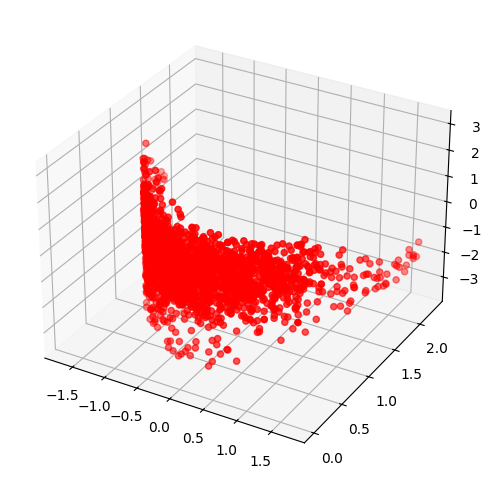

In [ ]:
def F_cylinder(x):
    x1,x2,x3 = x[0],x[1],x[2]
    return x1**2+(x2-2)**2-3

x0_cylinder = jnp.zeros(3).at[0].set(jnp.sqrt(3))

samples = PCN(F_cylinder,x0_cylinder)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(samples[0], samples[1], samples[2], color='red', marker='o')
plt.show()

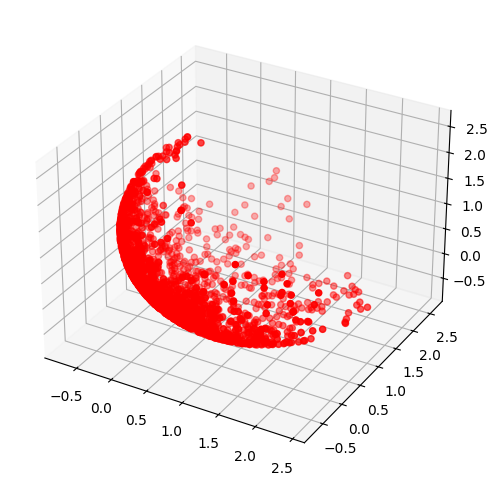

In [ ]:
def F(x):
    return jnp.dot(x-1,x-1)-3

x0 = jnp.zeros(3)

sphere_samples = PCN(F,x0)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(sphere_samples[0], sphere_samples[1], sphere_samples[2], color='red', marker='o')
plt.show()